# Efeito Chladni: uma aplicação da Função de Bessel

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 

$\quad$ As funções de Bessel são umas das funções especiais mais conhecidas e que, consequentemente, aparecem em inúmeros contextos da física. No `Notebook` iremos primeiramente considerar um modelo descrever a vibração de uma membrana circular, onde o resultado será dado em termos de uma função de Bessel. Logo em seguida, utilizaremos esse resultado para simular a física do Efeito Chladni, criando figuras que representam visialmente determinados padrões sonoros.  

## Importando bibliotecas

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator

## Informações sobre as bibliotecas

In [46]:
%load_ext version_information
%version_information Matplotlib, Numpy

Software versions
Python 3.12.7 64bit [MSC v.1929 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26200 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Sat Aug 29 15:29:23 2026 Hora oficial do Brasil

## 1. Introdução Teórica

Estaremos interessados em descrever os modos de vibração produzidos em uma membrana circular de raio $a$. Naturalmente para isso teremos que considerar a função de onda 
$$
\nabla^2 \phi (\mathbf{r}, t) - \frac{1}{c^2}\frac{\partial^2 \phi(\mathbf{r},t)}{\partial t^2} = 0.
\tag{1.1}
$$
Se pensarmos no comportamento de uma membrana circular enquanto elemento estrutural de um tambor, por exemplo, percebemos que as bordas ficam fixas indefinidamente. Assim, fisicamentetemos as condições de contorno na borda da membrana: $\phi(\mathbf{r} = a, \theta, t) = 0$ para $\forall \theta, t$. Com a modelagem do problema já feita, podemos sumarizar que queremos obter a forma da função $\phi(\mathbf{r}, t)$ que satisfaz tanto a Eq. (1.1) quanto à condição de contorno já apresentada.   

Como de praxe na física, a primeira tentativa de abordagem para esse problema é feita a partir da suposição de que a função requisitada será o produto entre uma função unicamente especial (isto é, dependente de $\mathbf{r}$) e outra dependente do tempo. Dessa forma, tem-se
$$
\phi (\vec{r},t) = F(\vec{r})T(t) = f(r)g(\theta)T(t).
\tag{1.2}
$$
Nossa suposição pode ir ainda mais além e impor que a função espacial será o produto entre uma função dependente do raio $r$ e uma outra dependente do ângulo polar $\theta$ no plano. Assim,
$$
\phi (\vec{r},t) = f(r)g(\theta)T(t)
$$

Seguinte o próximo passado clássico desse método de resolução de EDP, obtemos as seguintes EDO desacopladas
$$
\frac{d^2 T(t)}{dt^2} = -k^2c^2T(t),
\tag{1.3a}
$$
$$
\frac{d^2g(\theta)}{d\theta^2} = -\mu^2g(\theta),
\tag{1.3b}
$$

$$
r^2\frac{d^2f(x)}{dx^2} + x\frac{d f(x)}{dx} + (k^2x^2-\mu^2)f(x) = 0,
\tag{1.3c}
$$

onde $k$ e $\mu$ são constantes de separação e $x = kr$ é uma mudança de variável realizada para deixar a Eq. (1.3c) numa forma conveninente.

A primeira equação é a equação diferencial que descreve um oscilador harmônico com frequência $\omega_0 = ck$ e solução geral igual a 
$$
T(t) = \alpha \cos{(ckt)} + \beta \sin{(ckt)}.
$$

De forma análoga para a solução da segunda EDO,
$$
g(\theta) = A\cos{(\mu \theta)} + B\sin{(\mu \theta)}.
$$

Apesar da forma complicada da terceira equação diferencial, ela também é muito bem conhecida na física, denominada Equação de Bessel. Para o caso onde $\mu \in \mathbb{Z}$, a solução geral é
$$
f(r) = CJ_\mu (x) + D Y_\mu (x).
$$
No entanto, como $Y_\mu (x) \to \infty$ (MAIS OU MENOS INFIT?) à medida que $x \to 0$ (isto é, quando o raio $r \to 0$, bem no centro da membrana), temos que zerar a constante $D$, não permitindo esse estado não físico. Assim,
$$
f(r) = C J_\mu(kr).
$$

Agora já podemos aplicar a condição de contorno $\phi(r = a,\theta, t) = 0$, obtendo
$$
\phi (r = a, \theta, t) = 0 \implies f(r=a)g(\theta)T(t) = 0 \implies f(a) = 0 \implies J_{\mu}(ka) = 0
$$

$\quad$ Para que a condição $J_{\mu}(x) = 0$ seja satisfeira, o argumento $x$ tem que ser uma raiz da função de bessel de ordem $\mu$. Como a função de bessel é oscilatória, cruznado o eixo $x$ várias vezes, cada ordem pode (e tem) mais do que somente um zero. Logo, o argumento vai depender da ordem da função de bessel e de um número que o identifica como a n-ésima raiz. Dessa maneira,
$$
J_{\mu}(x) = 0 \implies x_{\mu \nu} = z_{\mu \nu}, 
$$
onde $z_{\mu \nu}$ é a $\nu$-ésima raiz da função de bessel do primeiro tipo de ordem $\mu$. Assim
$$
ka = z_{\mu \nu} \implies k_{\mu \nu} = \frac{z_{\mu \nu}}{a}.
$$
Por fim
$$
f(r) = CJ_{\mu}\left(\frac{z_{\mu \nu}}{a}r\right).
$$

Dessa maneira, já podemos determinar forma de $\phi(\mathbf{r}, t)$
$$
\phi_{\mu \nu}(r, \theta, t) = f(r)g(\theta)T(t) = CJ_u\left(\frac{z_{\mu \nu} r}{a}\right)(A_{\mu \nu}\cos{(\mu \theta)} + B_{\mu \nu}\sin{(\mu \theta)}) \left[ \alpha _{\mu \nu}\cos{\left(c\frac{z_{\mu \nu}}{a}t\right)} + \beta_{\mu \nu} \sin{\left(c\frac{z_{\mu \nu}}{a}t\right)}\right].
$$

Utilizando a identidade $\alpha \cos{x} + \beta \sin{x} = \sqrt{\alpha^2 + \beta^2}\cos{(x+x_0)}$, onde $x_0$ é representa uma fase,
$$
\phi_{\mu \nu}(r, \theta, t) = CJ_u\left(\frac{z_{\mu \nu} r}{a}\right)A^{\prime} \cos{(\mu \theta)} \alpha^{\prime} \cos{\left(c\frac{z_{\mu \nu}}{a}t\right)},
$$
com $A^{\prime}$ e $\alpha^{\prime}$ sendo novas constantes e as restrições $\mu \in \mathbb{Z}_{\geq 0}$, $\nu \in \mathbb{N}$.

Como as constantes apenas afetam o amplitude máxima da oscilação, podemos igualá-las todas a $1$ que ainda assim visualizaremos a física oscilatória dos modos. Desse modo, a solução final será 
$$
\phi_{\mu \nu}(r, \theta, t) = J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}.
\tag{}
$$ 





## 2. Simulação a vibração da membrana

$\quad$ Para a devida simulação, primeiro se faz necessário considerar uma discretização da nossa membrana. Isso é feito da maneira usual: geramos N valores igualmente espaçados entre $[0,a]$ para o raio $r$ e entre $[0,2\pi]$ para o ângulo polar $\theta$. Olhando de volta para Eq. (aa) é possível perceber que, uma vez que decidamos qual modo iremos simular, isto é, efetivamente escolhendo algum valor para $\mu$ e $\nu$, toda a parte espacial $J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}$ estará devidamente determinada, onde, se quisermos realizar a evolução temporal, apenas multiplicamos por $\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}$, desde um $t = 0$ até um $t = t_f$, com determinado número de passos. Feitas essas considerações, já podemos definir algumas variáveis para nossa simulação, onde escolheremos inicialmente $\mu = 2$ e $\nu = 1$.

In [104]:
# 1. Parâmetros do sistema
mu = 2          # Modo angular (número de diâmetros nodais).
nu = 1          # Modo radial (número de círculos nodais).
a = 1.0         # Raio da membrana.
c = 1.0         # Velocidade da onda.

# Obter a nu-ésima raiz de Bessel da ordem mu.
# sp.jn_zeros retorna as primeiras 'nu' raízes; pegamos a última ([nu-1]).
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

# 2. Criação da malha polar e conversão para cartesiana (pois fica mais fácil para plotar).
r = np.linspace(0, a, 80)
theta = np.linspace(0, 2 * np.pi, 80)
R, Theta = np.meshgrid(r, theta)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Parte espacial fixa da equação
spatial_part = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
z_max = np.max(np.abs(spatial_part))

Definida essa malha circular para o plano básico da membrana, podemos considerar que a coordenadas $z$ do nosso espaço será simplesmente o falor de $\phi_{\mu \nu}$ naquele ponto $(x,y).$

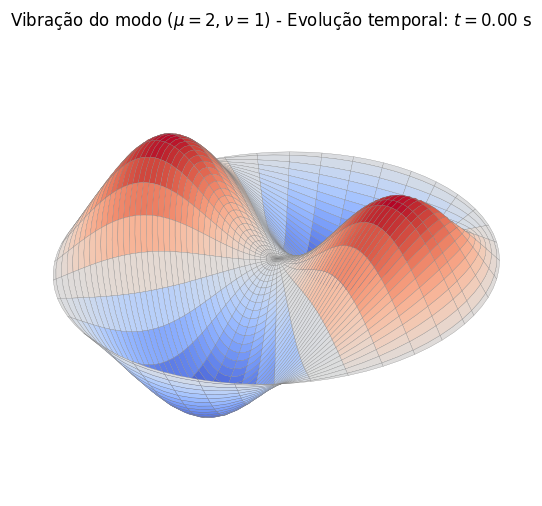

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

t = 0
Z = spatial_part * np.cos(z_munu * c * t / a)

surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

ax.set_xlim(-1.4 * z_max, 1.4 * z_max)
ax.set_ylim(-1.3 * z_max, 1.3 * z_max)
ax.set_zlim(-1.1 * z_max, 1.1 * z_max)
ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$ - Evolução temporal: $t = {t:.2f}$ s")
ax.set_axis_off()  # Oculta eixos para destacar a superfície

O plot anterior mostra simplesmente a membrana em $t = 0$. No entanto, agora podemos definir uma função que vai atualizando o valor de $t$ em pequenos incrementos $Delta t$, para que depois possamos gerar um GIF dessa evolução.

In [ ]:
# 3. Configuração do gráfico 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
plt.close()

def update(frame):
    ax.clear()
    t = frame * 0.05
    
    # Adiciona a evolução temporal cos(z_munu * c * t / a)
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

    ax.set_xlim(-1.4 * z_max, 1.4 * z_max)
    ax.set_ylim(-1.3 * z_max, 1.3 * z_max)
    ax.set_zlim(-1.1 * z_max, 1.1 * z_max)
    ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$ - Evolução temporal: $t = {t:.2f}$ s")
    ax.set_axis_off()  # Oculta eixos para destacar a superfície
    ax.plot
    return surf,


Agora vamos efetivamente gerar a animação

In [ ]:
frames = 80 # Efetivamente o tempo final.
anim = FuncAnimation(fig, update, frames=frames, interval=40, blit=False)

# Salvando como GIF (opcional):
anim.save("Membrana_Vibratoria_2_1.gif", writer="pillow", fps=25)

Comentários sobre a animação

## 3. Figuras de Chladni

A experiência de observar uma figura de Chladni é o mais próximo que nós temos de poder "ver o som". O ocorre quando a frequência de uma força externa numa dada superfície coincide com a frequência de oscilação natural dessa superfície. De forma resumida, a figura de Chladni ocorre quando colocamos um dado número de partículas sobre essa superfície, de tal forma que elas são influenciadas pela oscilação e forma um dado padrão. Pode-se observar Chladni em superfície de diferentes geometrias, tanto quadrada quanto circular, até mesmo triangular. Nessa seção simularemos a formação de uma Figura de Chladni na mesma grade circular que estávemos utilizando até esse momento. 

ADICIOANR IMAGEM DE UMA FIGURA DE CHLADNI

Aqui utilizaremos o modelo de que, para a formação do padrão de Chladni, as partículas (por exemplo, poderia ser grãos de areia) se movem em direção ao negativo do gradiente da nossa oscilação. Isto é, a partícula efetivamente sente uma força ao ser forçada a entrar em movimento por causa da oscilação vertical da membrana. No entanto, para melhor simular as condições física dessa interação, precisamos também adicionar um fator aleatório devido à não pontualidade dos grãos.

Para iniciar a simulação, definimos novamente as propriedades fundamentais do sistema física e numericamente. Nesta etapa, determinamos os números quânticos da vibração ($\mu$ e $\nu$), o raio da membrana, a densidade de grãos de areia e os fatores que regem a dinâmica das partículas (a velocidade do movimento determinístico e a intensidade da agitação estocástica).

In [ ]:
# Utilizaremos o mesmo modo angular, modo radial  e raio de antes.

N_particles = 8000  # Quantidade de grãos de areia.
step_size = 0.05    # Velocidade de migração
noise_std = 0.005   # Agitação estocástica (ruído)

A aplicação da máscara atua como um filtro espacial restritivo, funcionando de maneira análoga a uma abertura física que delimita a região de interesse. Ao zerar todos os valores fora de um raio estipulado, a máscara impede que ruídos de borda e artefatos indesejados interfiram nas extremidades da matriz, concentrando a análise exclusivamente na área útil do fenômeno. Dentro desse domínio validado, o cálculo do gradiente entra para quantificar as taxas de variação espacial da distribuição. Computar o gradiente transforma a superfície estática em um mapa vetorial de inclinações e derivadas, evidenciando as transições de intensidade, a direção das mudanças mais abruptas e destacando precisamente onde ocorrem os contornos e vales locais. Para que toda essa informação seja manipulada de forma geométrica e fluida, o uso de interpoladores se torna indispensável. Os interpoladores pegam os dados rigorosamente limitados aos pontos discretos e constroem uma aproximação contínua da superfície, permitindo estimar valores em coordenadas fracionárias arbitrárias. Essa ferramenta oferece a liberdade necessária para rotacionar, transladar ou redimensionar a distribuição original sem perda de fidelidade, calculando transições suaves e exatas entre os pontos sempre que a aplicação exigir dados em coordenadas que não caiam perfeitamente sobre os índices inteiros iniciais.

In [137]:
# Criação de uma grade cartesiana fina para calcular derivadas numéricas
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X, Y = np.meshgrid(x_grid, y_grid)

R = np.hypot(X, Y)
Theta = np.arctan2(Y, X)
mask = R <= a  # Máscara para manter cálculos dentro do círculo

# Calcula a raiz de Bessel e o módulo da amplitude (Potencial U)
z_munu = sp.jn_zeros(mu, nu)[nu - 1]
phi = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
phi[~mask] = 0
U = np.abs(phi)  # A areia foge dos picos de amplitude

# Gradiente numérico do potencial
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y  # Força aponta contra o gradiente (para o zero)

# Interpoladores para calcular a força em qualquer ponto (x,y)
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)


Com o campo de força pronto e as regras de movimento estabelecidas, o próximo passo é posicionar os grãos de areia antes da "batida" no tambor. Precisamos garantir que as partículas comecem uniformemente espalhadas por toda a superfície da membrana, sem se concentrarem artificialmente no centro. Para obter uma distribuição de probabilidade uniforme em um disco, aplicamos a raiz quadrada sobre os valores aleatórios do raio (**r_init**), equilibrando a área e evitando distorções geométricas. Em seguida, convertemos essas posições de volta para coordenadas cartesianas para facilitar o cálculo do deslocamento durante a animação.

In [167]:
# Espalha partículas aleatoriamente dentro do círculo
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)
pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)

Visualizando a configuração inicial

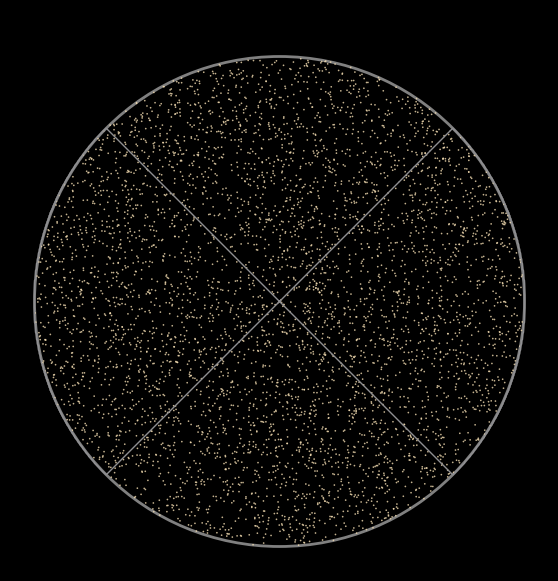

In [168]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')
ax.set_facecolor('black')
ax.set_aspect('equal')
ax.set_xlim(-1.1*a, 1.1*a)
ax.set_ylim(-1.1*a, 1.1*a)
ax.axis('off')
ax.set_title(f"Posição Inicial das Partículas na Membrana Circular")


# Desenha as linhas nodais teóricas ao fundo (opcional, em cinza bem fraco)
ax.contour(X, Y, phi, levels=[0], colors="#8F8F92", linewidths=1)
# Borda da membrana
circulo = plt.Circle((0, 0), a, color='gray', fill=False, linewidth=2)
ax.add_patch(circulo)

# Plot inicial das partículas
scatter = ax.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

Novamente podemos definir uma função atualização para evoluir a configuração em pequenos imcrementos de tempo, dessa vez se atentando que precisamos calcular a força sobre as partículas em cada passo.

In [169]:
def update(frame):
    global pos_x, pos_y
    
    # Prepara coordenadas para o interpolador (y, x)
    pts = np.vstack((pos_y, pos_x)).T
    
    # Interpola a força vetorial no ponto exato de cada partícula
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)
    
    # Atualiza posição = Força Determinística + Ruído Gaussiano
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)
    
    # Condição de Contorno: Mantém a areia dentro do tambor
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = 999
    pos_y[fora] = 999
    
    # Atualiza o gráfico
    scatter.set_offsets(np.c_[pos_x, pos_y])
    return scatter,

Agora sim podemos já gerar o GIF da evolução

In [170]:
anim = FuncAnimation(fig, update, frames=50, interval=80, blit=True)

anim.save("Figura_de_Chlaidni.gif", writer="pillow", fps=10)

Comparando com a nossa visualização da oscilação na membrana, vemos que naturalmente as partículas migram para a região onde o efeito da oscilação é pequeno ou mesmo nulo, ou seja, elas migram para as redondezas dos nós.

## 4. Visualizando tudo ao mesmo tempo

Agora podemos tentar visualizar tudo ao mesmo tempo lado a lado, inclusive para um caso mais complexos de $mu$ e $nu$. Por complexo eu quero dizer uma configuração de oscilação com mais nós.

In [174]:
mu = 6          # Modo angular (número de diâmetros nodais)
nu = 6          # Modo radial (número de círculos nodais)
a = 1.0         # Raio da membrana
c = 1.0         # Velocidade da onda

# Parâmetros da "Areia" (Chladni)
N_particles = 10000  # Quantidade de partículas
step_size = 0.02    # Velocidade de migração
noise_std = 0.002   # Ruído aleatório (agitação estocástica)

# Obter a nu-ésima raiz de Bessel da ordem mu
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

Plot da oscilação em si.

In [175]:
r_3d = np.linspace(0, a, 100)
theta_3d = np.linspace(0, 2 * np.pi, 100)
R_3d, Theta_3d = np.meshgrid(r_3d, theta_3d)

X_3d = R_3d * np.cos(Theta_3d)
Y_3d = R_3d * np.sin(Theta_3d)

# Parte espacial fixa da equação
spatial_part = sp.jn(mu, z_munu * R_3d / a) * np.cos(mu * Theta_3d)
z_max = np.max(np.abs(spatial_part))

Plot da figura de chlaidni

In [176]:
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X_2d, Y_2d = np.meshgrid(x_grid, y_grid)

R_2d = np.hypot(X_2d, Y_2d)
Theta_2d = np.arctan2(Y_2d, X_2d)
mask = R_2d <= a

# Potencial U (módulo da amplitude)
phi = sp.jn(mu, z_munu * R_2d / a) * np.cos(mu * Theta_2d)
phi[~mask] = 0
U = np.abs(phi)

# Gradiente e Interpolador
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y  # Força empurra para o zero
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)

# Posições iniciais das partículas
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)
pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)


Configuração inicial

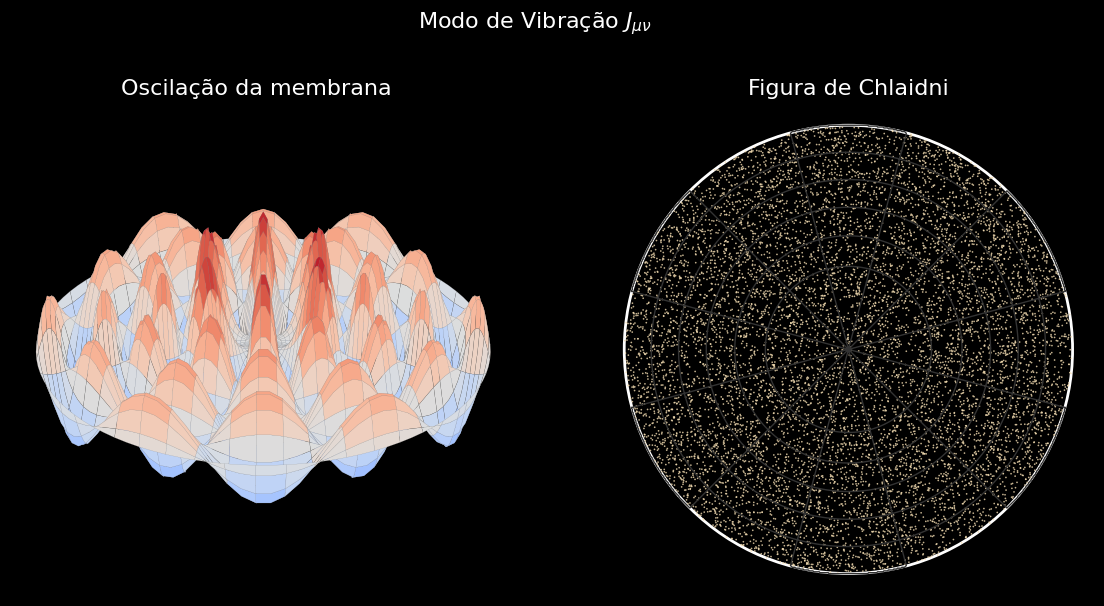

In [196]:
fig = plt.figure(figsize=(14, 7), facecolor='black')

# Subplot 1: Membrana 3D (Esquerda)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('black')
ax1.set_axis_off()
ax1.set_xlim(-0.7 * a, 0.7 * a)
ax1.set_ylim(-0.7 * a, 0.7 * a)
ax1.set_title(f'Oscilação da membrana', color='white', fontsize=16)

# Subplot 2: Chladni 2D (Direita)
ax2 = fig.add_subplot(122)
ax2.set_facecolor('black')
ax2.set_aspect('equal')
ax2.set_xlim(-1.1*a, 1.1*a)
ax2.set_ylim(-1.1*a, 1.1*a)
ax2.axis('off')
ax2.set_title(f'Figura de Chlaidni', color='white', fontsize=16)


# Elementos estáticos do 2D
circulo = plt.Circle((0, 0), a, color='white', fill=False, linewidth=2)
ax2.add_patch(circulo)
ax2.contour(X_2d, Y_2d, phi, levels=[0], colors='#333333', linewidths=1) # Linhas nodais teóricas
scatter = ax2.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

fig.suptitle(r'Modo de Vibração $J_{\mu \nu}$', color='white', fontsize=16)


t=0
Z = spatial_part * np.cos(z_munu * c * t / a)
    
surf = ax1.plot_surface(
        X_3d, Y_3d, Z, 
        cmap='coolwarm', 
        vmin=-z_max, vmax=z_max, 
        linewidth=0.1, edgecolor='gray', antialiased=True
)

Função de atualização

In [197]:

def update(frame):
    global pos_x, pos_y
    t = frame * 0.02
    
    # ------------------------------------
    # Atualiza Lado Esquerdo (3D)
    # ------------------------------------
    ax1.clear()
    ax1.set_facecolor('black')
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax1.plot_surface(
        X_3d, Y_3d, Z, 
        cmap='coolwarm', 
        vmin=-z_max, vmax=z_max, 
        linewidth=0.1, edgecolor='gray', antialiased=True
    )
    
    # Reconfigura os limites e oculta eixos (pois ax1.clear() reseta isso)
    ax1.set_xlim(-0.7 * a, 0.7 * a)
    ax1.set_ylim(-0.7 * a, 0.7 * a)
    ax1.set_zlim(-1.2 * z_max, 1.2 * z_max)
    ax1.set_axis_off()
    ax1.set_title(f"Oscilação da Mebrana - Evolução: $t = {t:.2f}$ s", color='white', pad=10)

    # ------------------------------------
    # Atualiza Lado Direito (2D Areia)
    # ------------------------------------
    pts = np.vstack((pos_y, pos_x)).T
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)

    # Movimento: Força Determinística + Ruído (agitação)
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)

    # Condição de Contorno
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = (pos_x[fora] / r_atual[fora]) * a
    pos_y[fora] = (pos_y[fora] / r_atual[fora]) * a

    scatter.set_offsets(np.c_[pos_x, pos_y])
    ax2.set_title("Formação da Figura de Chladni", color='white', pad=10)
    
    return surf, scatter

Efetuando a animação

In [198]:
# Criação da Animação (150 frames formam um loop legal dependendo do tempo)
ani = FuncAnimation(fig, update, frames=50, interval=50, blit=False)

ani.save('chladni_oscilacao_combinada.gif', writer='pillow', fps=10)

Comentários sobre a animação.

## 5. Conclusão

## Referências


**[1]** 

**[2]**



O. Devauchelle, P. Popović, P. Szymczak, A. Abramian, A. Lazarus. Thermodynamics of bouncing grains.
Physical Review E , 2026, 114 (2), pp.025420. ⟨10.1103/zlsc-w7m4⟩. ⟨hal-05725479⟩